In [1]:
import cv2, matplotlib.pyplot as plt, os, random
from pathlib import Path
from ultralytics import YOLO

model_path = Path("runs/detect/runs/ir_detector/weights/best.pt")
model = YOLO(model_path)

# Run prediction on test set
results = model.predict(
    source="../data/test/images",
    conf=0.5,
    save=True,
    project="../runs",
    name="ir_predictions"
)

# Print detections
for r in results:
    print(f"\nImage: {r.path}")
    for box in r.boxes:
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"  → {model.names[cls]}: {conf:.2f}")


image 1/108 c:\Hamo\Courses\University\Semester 6\Visual Recognition\infrared-object-detector\notebooks\..\data\Test\images\ir100_jpg.rf.233104e80cfc777c03b2438015551c7b.jpg: 416x416 1 bicycle, 3 cars, 2 peoples, 9.9ms
image 2/108 c:\Hamo\Courses\University\Semester 6\Visual Recognition\infrared-object-detector\notebooks\..\data\Test\images\ir101_jpg.rf.2ef146c0c9471e35314bc6c2bb180bf5.jpg: 416x416 2 bicycles, 3 cars, 1 people, 14.8ms
image 3/108 c:\Hamo\Courses\University\Semester 6\Visual Recognition\infrared-object-detector\notebooks\..\data\Test\images\ir102_jpg.rf.4fa178575cdf89d9f744fa3e7b92d616.jpg: 416x416 1 bicycle, 3 cars, 1 people, 14.5ms
image 4/108 c:\Hamo\Courses\University\Semester 6\Visual Recognition\infrared-object-detector\notebooks\..\data\Test\images\ir103_jpg.rf.ac9023b8432589d9516e084505de7ae4.jpg: 416x416 2 bicycles, 3 cars, 2 peoples, 7.9ms
image 5/108 c:\Hamo\Courses\University\Semester 6\Visual Recognition\infrared-object-detector\notebooks\..\data\Test\imag

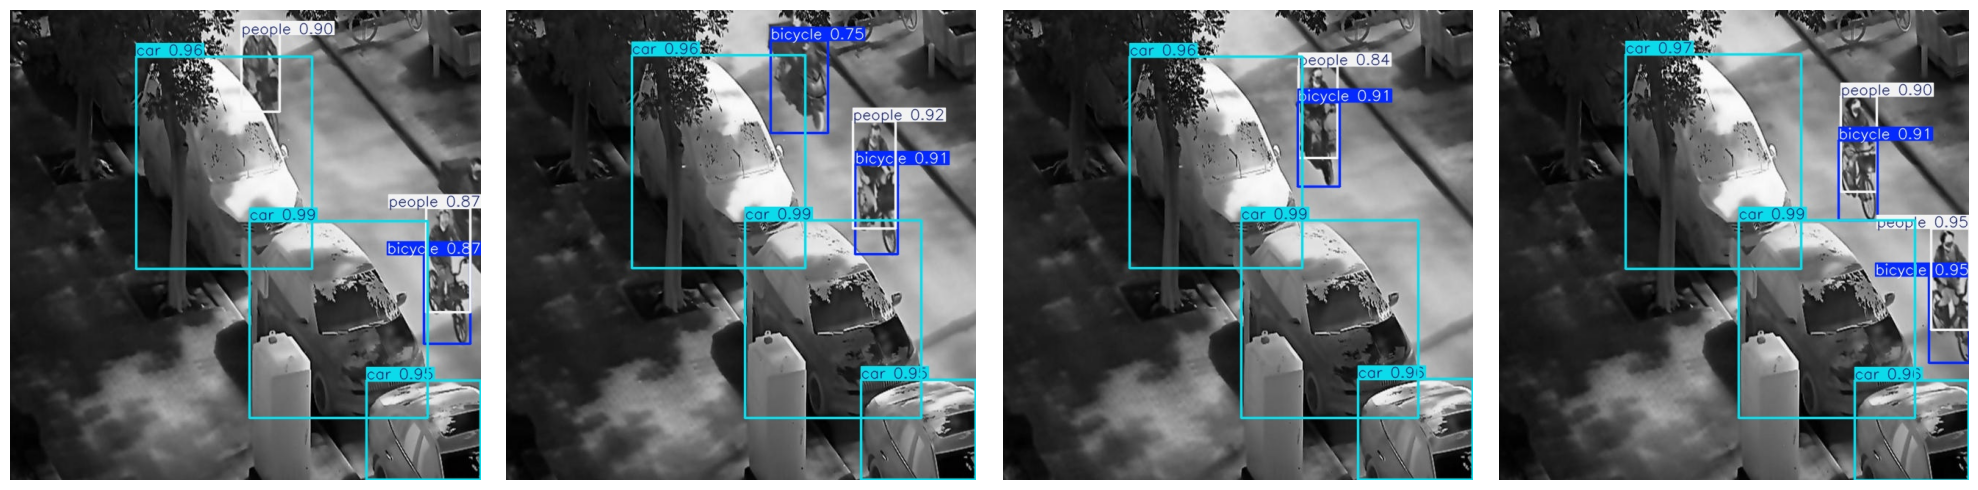

In [16]:
from pathlib import Path

result_dir = Path("runs/runs/ir_predictions")

imgs = list(result_dir.iterdir())[:4]

fig, axes = plt.subplots(1, len(imgs), figsize=(20,5))
for ax, img_path in zip(axes, imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.savefig("../predictions_preview.png")
plt.show()